In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

In [ ]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


In [ ]:
# Select only digits 0 and 1
train_filter = (y_train == 0) | (y_train == 1)
test_filter = (y_test == 0) | (y_test == 1)

X_train_binary = X_train[train_filter]
y_train_binary = y_train[train_filter]

X_test_binary = X_test[test_filter]
y_test_binary = y_test[test_filter]

print("Training images:", X_train_binary.shape)
print("Testing images:", X_test_binary.shape)

Training images: (12665, 28, 28)
Testing images: (2115, 28, 28)


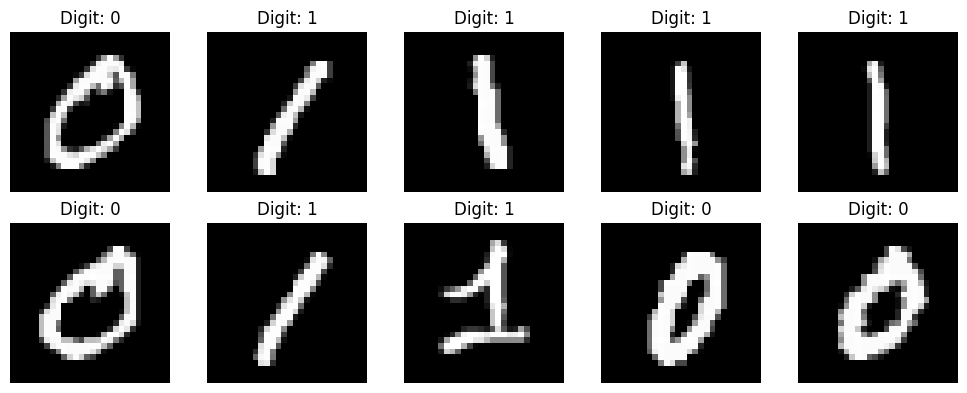

In [ ]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_binary[i], cmap="gray")
    plt.title("Digit: " + str(y_train_binary[i]))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
X_train_binary = X_train_binary.astype("float32") / 255.0
X_test_binary = X_test_binary.astype("float32") / 255.0

In [ ]:
# Flatten images
X_train_flat = X_train_binary.reshape(X_train_binary.shape[0], 784)
X_test_flat = X_test_binary.reshape(X_test_binary.shape[0], 784)

print("Training data after flattening:", X_train_flat.shape)
print("Testing data after flattening:", X_test_flat.shape)

Training data after flattening: (12665, 784)
Testing data after flattening: (2115, 784)


In [ ]:
# Create Logistic Regression model
discriminative_model = LogisticRegression(
    max_iter=1000
)

# Train the model
discriminative_model.fit(X_train_flat, y_train_binary)

print("Discriminative model training completed.")

Discriminative model training completed.


In [ ]:
# Predict test images
y_pred = discriminative_model.predict(X_test_flat)

# Calculate accuracy
accuracy = accuracy_score(y_test_binary, y_pred)

print("Discriminative Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Discriminative Model Accuracy: 0.9995271867612293
Accuracy Percentage: 99.95271867612293 %


In [ ]:
print(classification_report(y_test_binary, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      1.00      1.00      1135

    accuracy                           1.00      2115
   macro avg       1.00      1.00      1.00      2115
weighted avg       1.00      1.00      1.00      2115



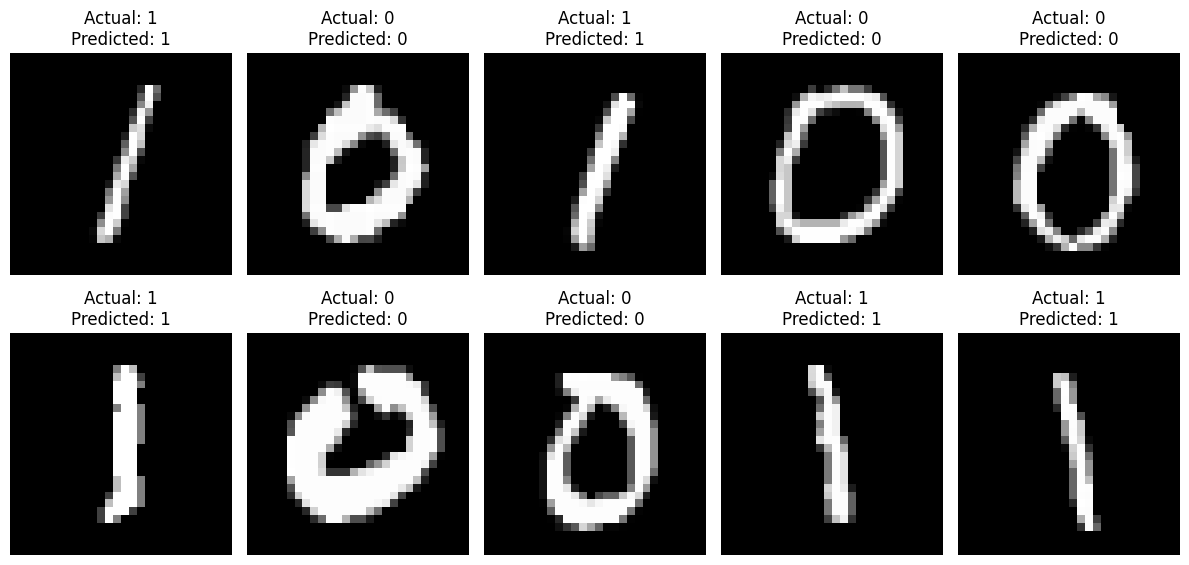

In [ ]:
plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test_binary[i], cmap="gray")
    plt.title(
        "Actual: " + str(y_test_binary[i]) +
        "\nPredicted: " + str(y_pred[i])
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Combine training and testing images for the generative experiment
X_autoencoder = np.concatenate(
    [X_train_binary, X_test_binary],
    axis=0
)

# Flatten images
X_autoencoder_flat = X_autoencoder.reshape(
    X_autoencoder.shape[0], 784
)

print("Autoencoder input shape:", X_autoencoder_flat.shape)

Autoencoder input shape: (14780, 784)


In [ ]:
# Input layer
input_img = Input(shape=(784,))

# Encoder
encoded = Dense(128, activation="relu")(input_img)
encoded = Dense(64, activation="relu")(encoded)
encoded = Dense(32, activation="relu")(encoded)

# Decoder
decoded = Dense(64, activation="relu")(encoded)
decoded = Dense(128, activation="relu")(decoded)
decoded = Dense(784, activation="sigmoid")(decoded)

# Complete Autoencoder
autoencoder = Model(input_img, decoded)

# Compile model
autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy"
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = autoencoder.fit(
    X_autoencoder_flat,
    X_autoencoder_flat,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_split=0.1
)

Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.3498 - val_loss: 0.1878
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.1689 - val_loss: 0.1470
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.1364 - val_loss: 0.1269
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.1212 - val_loss: 0.1140
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.1128 - val_loss: 0.1098
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.1084 - val_loss: 0.1044
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1040 - val_loss: 0.1003
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1001 - val_loss: 0.0965
Epoch 9/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0961 - val_loss: 0.0929
Epoch 10/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0929 - val_loss: 0.0909


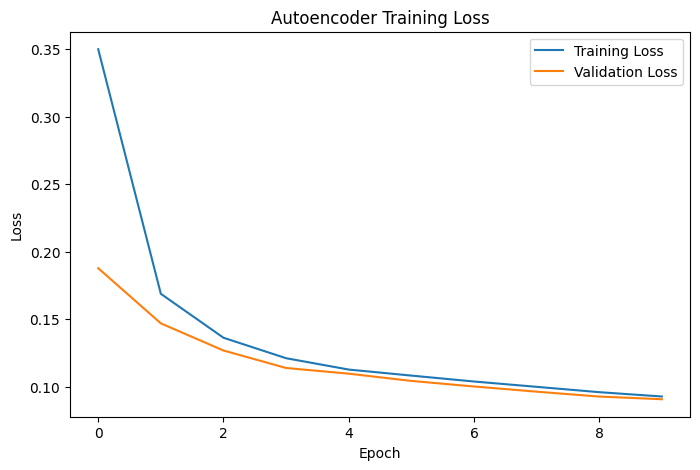

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training Loss")
plt.legend()

plt.show()

In [ ]:
# Select some real images
sample_images = X_test_binary[:10]

# Flatten
sample_flat = sample_images.reshape(10, 784)

# Generate reconstructed images
generated_images = autoencoder.predict(sample_flat)

# Reshape back to 28 x 28
generated_images = generated_images.reshape(10, 28, 28)

print("Generated image shape:", generated_images.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Generated image shape: (10, 28, 28)


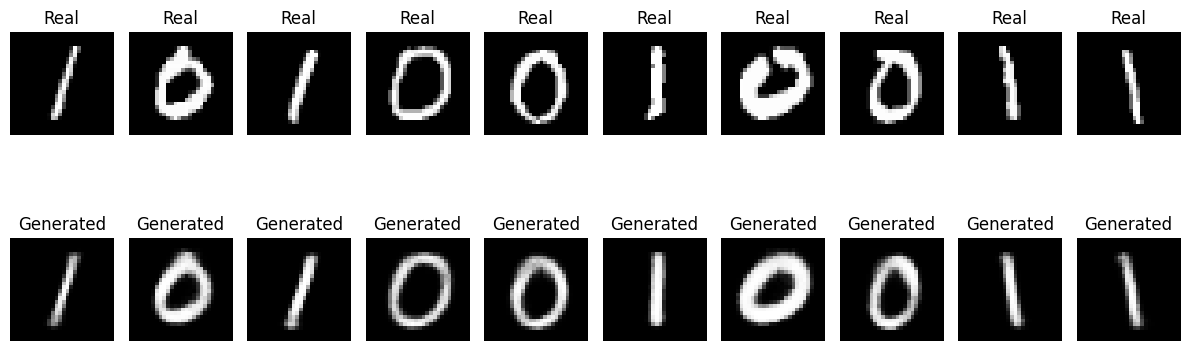

In [ ]:
plt.figure(figsize=(12, 5))

for i in range(10):

    # Real image
    plt.subplot(2, 10, i + 1)
    plt.imshow(sample_images[i], cmap="gray")
    plt.title("Real")
    plt.axis("off")

    # Generated/reconstructed image
    plt.subplot(2, 10, i + 11)
    plt.imshow(generated_images[i], cmap="gray")
    plt.title("Generated")
    plt.axis("off")

plt.tight_layout()
plt.show()

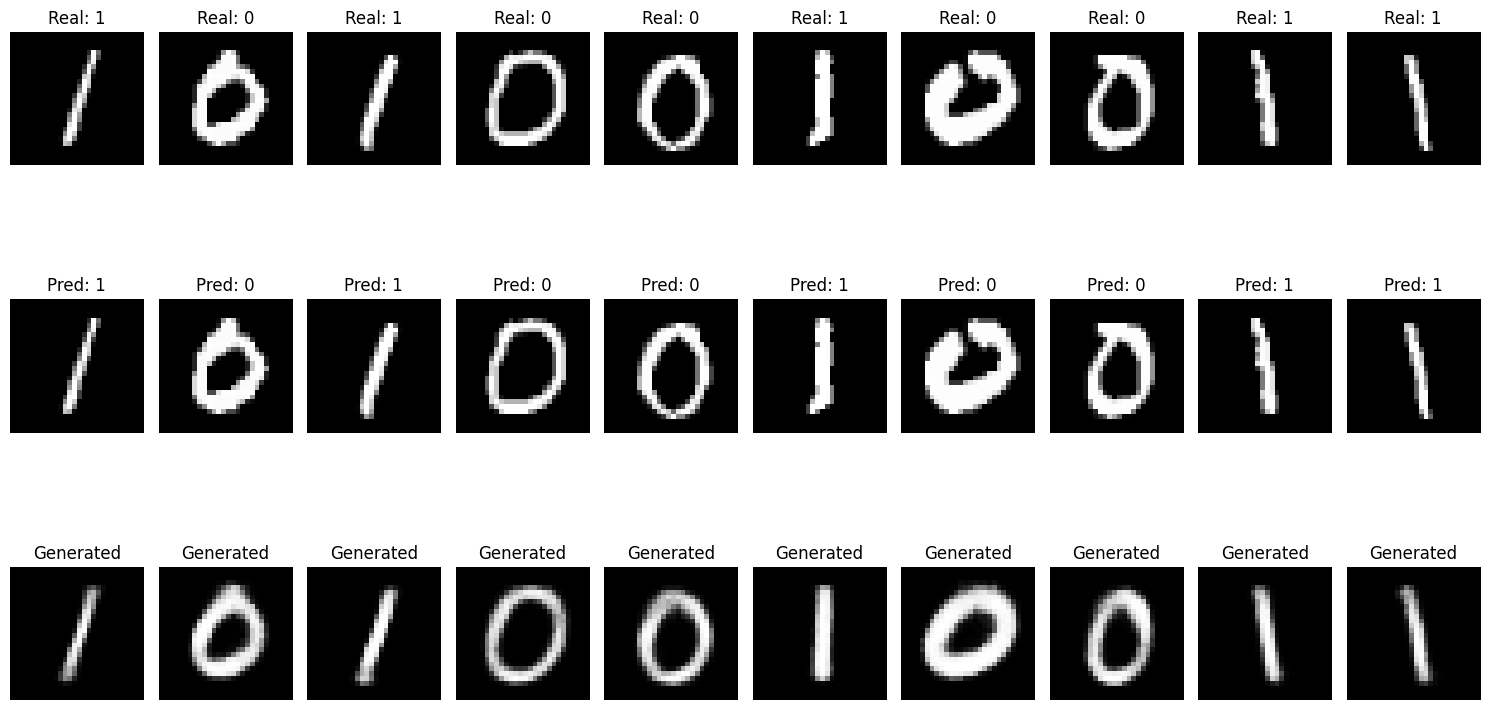

In [ ]:
plt.figure(figsize=(15, 9))

for i in range(10):

    # Real image
    plt.subplot(3, 10, i + 1)
    plt.imshow(X_test_binary[i], cmap="gray")
    plt.title("Real: " + str(y_test_binary[i]))
    plt.axis("off")

    # Prediction
    plt.subplot(3, 10, i + 11)
    plt.imshow(X_test_binary[i], cmap="gray")
    plt.title("Pred: " + str(y_pred[i]))
    plt.axis("off")

    # Generated image
    plt.subplot(3, 10, i + 21)
    plt.imshow(generated_images[i], cmap="gray")
    plt.title("Generated")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Create an encoder model
encoder = Model(input_img, encoded)

# Encode some images
encoded_images = encoder.predict(sample_flat)

print("Original image size:", sample_flat.shape[1])
print("Compressed representation size:", encoded_images.shape[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Original image size: 784
Compressed representation size: 32
